In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
from google.colab import files

uploaded = files.upload()

Saving DailyDelhiClimateTest.csv to DailyDelhiClimateTest.csv
Saving DailyDelhiClimateTrain.csv to DailyDelhiClimateTrain.csv


In [3]:
df = pd.read_csv(list(uploaded.keys())[0])

df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [5]:
temperature_data = df['meantemp'].values.reshape(-1,1)

print(temperature_data.shape)

(114, 1)


In [6]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(temperature_data)

In [7]:
sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(84, 30)
(84,)


In [8]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(X.shape)

(84, 30, 1)


In [9]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 67
Testing Samples: 17


In [10]:
model = Sequential()

model.add(LSTM(
    units=64,
    return_sequences=True,
    input_shape=(X_train.shape[1],1)
))

model.add(Dropout(0.2))

model.add(LSTM(
    units=64,
    return_sequences=False
))

model.add(Dropout(0.2))

model.add(Dense(25))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,571 (201.45 KB)

 Trainable params: 51,571 (201.45 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 467ms/step - loss: 0.3338 - val_loss: 0.4426
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.1219 - val_loss: 0.0665
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0273 - val_loss: 0.0580
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0451 - val_loss: 0.0148
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0209 - val_loss: 0.0261
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0199 - val_loss: 0.0553
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0287 - val_loss: 0.0635
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0264 - val_loss: 0.0432
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0206 - val_loss: 0.0188
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0178 - val_loss: 0.0097
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0148 - val_loss: 0.0094
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0174 - val_loss: 0.0093


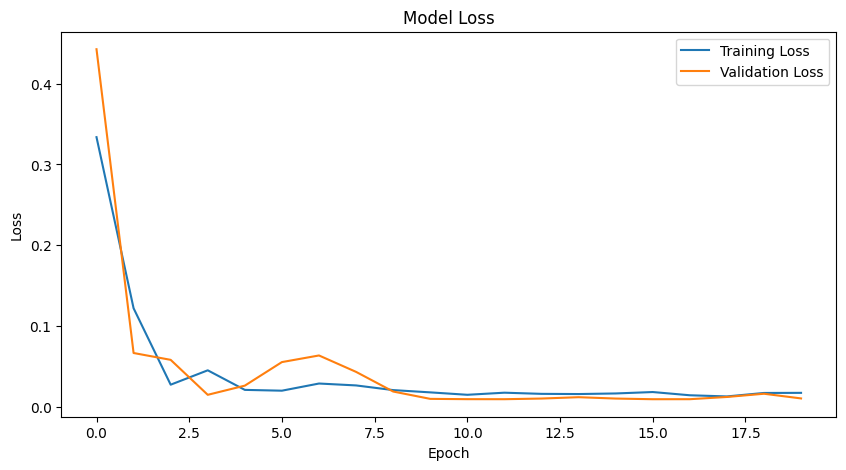

In [12]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [13]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
actual = scaler.inverse_transform(y_test.reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step


In [14]:
rmse = np.sqrt(mean_squared_error(actual, predictions))

print("RMSE:", rmse)

RMSE: 2.3829115314540843


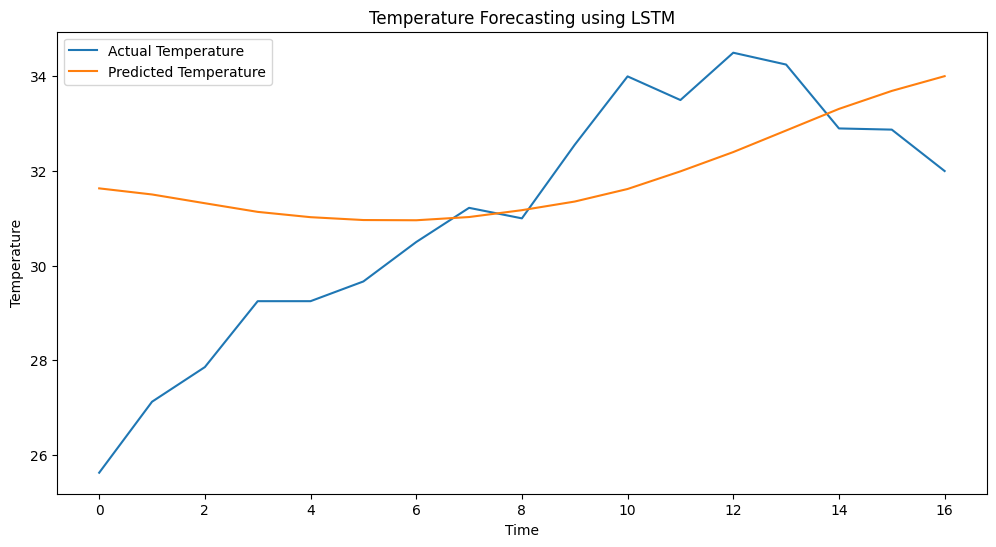

In [15]:
plt.figure(figsize=(12,6))

plt.plot(actual, label='Actual Temperature')
plt.plot(predictions, label='Predicted Temperature')

plt.title('Temperature Forecasting using LSTM')
plt.xlabel('Time')
plt.ylabel('Temperature')

plt.legend()
plt.show()

In [16]:
last_30_days = scaled_data[-30:]

X_future = np.array([last_30_days])
X_future = X_future.reshape((1,30,1))

future_temp = model.predict(X_future)

future_temp = scaler.inverse_transform(future_temp)

print("Predicted Next Day Temperature:")
print(future_temp[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step
Predicted Next Day Temperature:
34.220627
